In [78]:
import pandas as pd
import matplotlib.pyplot as plt

We're relying on the UK cleaned transactions file created in notebook 02.

In [79]:
df_transactions = pd.read_csv('../data/transactions_uk_cleaned.csv', parse_dates=['InvoiceDate'])
df_transactions.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0


In [80]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 741301 entries, 0 to 741300
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      741301 non-null  object        
 1   StockCode    741301 non-null  object        
 2   Quantity     741301 non-null  int64         
 3   InvoiceDate  741301 non-null  datetime64[ns]
 4   Price        741301 non-null  float64       
 5   Customer ID  741301 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 33.9+ MB


## Add transaction-level features

Most feature engineering will be performed later on the customer-level dataset after aggregating transactions. At this stage, add a small set of transaction-level features that will support that downstream transformation.

In [81]:
# row total price 
df_transactions["LinePrice"] = df_transactions["Quantity"] * df_transactions["Price"]

df_transactions.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,LinePrice
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,83.4
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,81.0
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,81.0
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,100.8
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,30.0


## Group by invoice and add aggregations

In [82]:
groupping_invoice = df_transactions.groupby('Invoice').agg(
    customer_id=('Customer ID', 'first'),  
    invoice_datetime=('InvoiceDate', 'first'),
    invoice_total_amount=('LinePrice', 'sum'),
    min_unit_price=('Price', 'min'),
    max_unit_price=('Price', 'max'),
    avg_unit_price=('Price', 'mean'),
    total_quantity=('Quantity', 'sum'),
    unique_item_count=('StockCode', 'nunique')    
)

In [83]:
groupping_invoice['is_cancelled'] = groupping_invoice.index.str.startswith("C", na=False)
groupping_invoice['invoice_hour'] = groupping_invoice['invoice_datetime'].dt.hour
groupping_invoice['day_of_week'] = groupping_invoice['invoice_datetime'].dt.dayofweek
groupping_invoice['invoice_month'] = groupping_invoice['invoice_datetime'].dt.month
groupping_invoice['invoice_year'] = groupping_invoice['invoice_datetime'].dt.year

groupping_invoice.head()


,customer_id,invoice_datetime,invoice_total_amount,min_unit_price,max_unit_price,avg_unit_price,total_quantity,unique_item_count,is_cancelled,invoice_hour,day_of_week,invoice_month,invoice_year
Invoice,,,,,,,,,,,,,
489434,13085.0,2009-12-01 07:45:00,505.30,1.25,6.95,4.081250,166,8,False,7,1,12,2009
489435,13085.0,2009-12-01 07:46:00,145.80,1.65,3.75,2.625000,60,4,False,7,1,12,2009
489436,13078.0,2009-12-01 09:06:00,630.33,1.25,8.50,3.730526,193,19,False,9,1,12,2009
489437,15362.0,2009-12-01 09:08:00,310.75,0.65,9.95,3.628261,145,23,False,9,1,12,2009
489438,18102.0,2009-12-01 09:24:00,2286.24,0.98,6.40,2.591176,826,17,False,9,1,12,2009


### Invoice-Level Features Documentation

| Field | Description | Clustering Value | Anomaly Detection Value |
|---|---|---|---|
| `customer_id` | Unique customer identifier for the invoice | Links invoices to customers for downstream aggregation | Identifies orphaned/mislinked records |
| `invoice_datetime` | Timestamp of invoice creation | Combined with temporal features for shopping pattern segmentation | Detects unusual transaction timing |
| `invoice_total_amount` | Sum of all line items (quantity × unit price) | Segments customers by spending levels; identifies bulk vs. small-order buyers | Detects unusually high/low spending invoices; potential fraud/errors |
| `min_unit_price` | Lowest per-unit price in the invoice | Indicates product mix quality; budget-conscious shopper signal | Detects suspicious pricing (e.g., 0 or negative prices) |
| `max_unit_price` | Highest per-unit price in the invoice | Indicates premium product purchases; luxury shopper segment | Detects extreme outlier prices |
| `avg_unit_price` | Mean per-unit price across all items in invoice | Distinguishes premium from value shoppers; product mix diversity | Detects inconsistent pricing patterns |
| `total_quantity` | Sum of units purchased in the invoice | Bulk buyers vs. individual item buyers; order size segmentation | Unusually large/small orders; potential data errors |
| `unique_item_count` | Number of distinct products in the invoice | Product diversity preference; one-item vs. multi-item buyers | Suspicious uniformity or excessive variety |
| `is_cancelled` | Boolean flag: invoice starts with "C" prefix | Separates normal from cancelled transactions for separate analysis | Identifies cancellation patterns (fraud indicator) |
| `invoice_hour` | Hour of day (0-23) when invoice was created | Time-of-day shopping behavior; night vs. day shoppers | Detects off-hours transactions (potential automated/fraudulent) |
| `day_of_week` | Day of week (0=Monday, 6=Sunday) | Weekly shopping patterns; weekend vs. weekday shoppers | Detects anomalous day-of-week patterns |
| `invoice_month` | Month of year (1-12) | Seasonal shopping patterns; holiday vs. off-season | Detects out-of-season anomalies |
| `invoice_year` | Year of transaction | Temporal trends; cohort analysis | Structural breaks in behavior |

**Note on naming convention:** Field names use `{aggregation_level}_{metric_name}` pattern. This scales cleanly when creating customer-level aggregations later (e.g., `customer_total_amount`, `customer_avg_unit_price`, `customer_unique_item_count`).

## Plot distribution of invoice columns

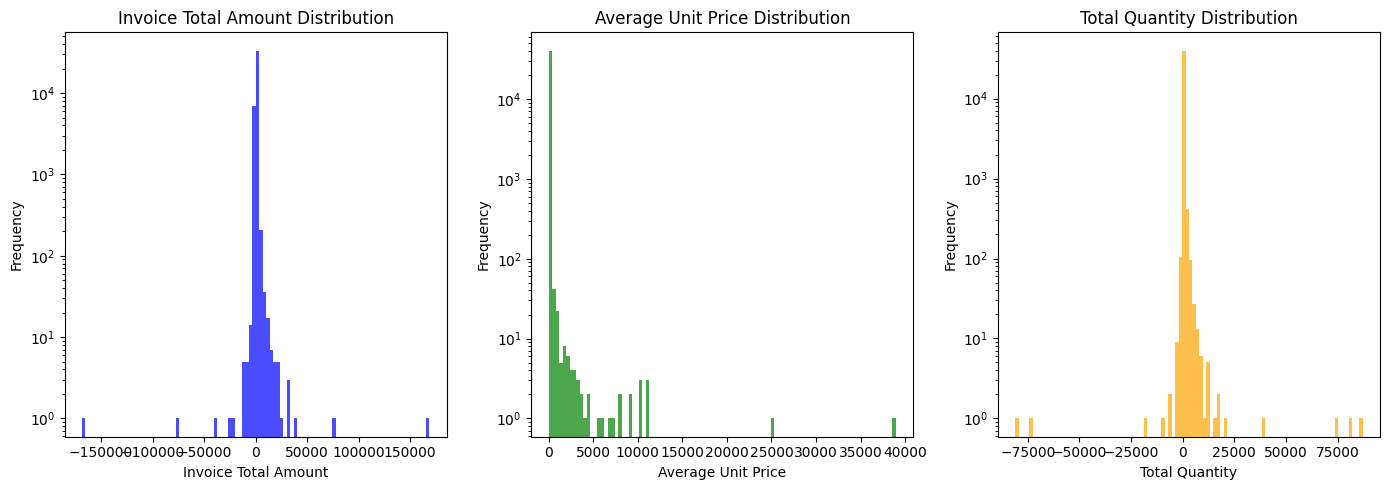

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# plot distribution of invoice total amount
groupping_invoice['invoice_total_amount'].plot.hist(bins=100, log=True, ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('Invoice Total Amount Distribution')
axes[0].set_xlabel('Invoice Total Amount')

# plot distribution of average unit price
groupping_invoice['avg_unit_price'].plot.hist(bins=100, log=True, ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('Average Unit Price Distribution')
axes[1].set_xlabel('Average Unit Price')

# plot distribution of total quantity
groupping_invoice['total_quantity'].plot.hist(bins=100, ax=axes[2], log=True, color='orange', alpha=0.7)
axes[2].set_title('Total Quantity Distribution')
axes[2].set_xlabel('Total Quantity')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Quantity Distribution Insights

The distribution shows a significant number of transactions with large quantities (25K+ items). This pattern suggests bulk or wholesale orders rather than typical consumer purchases, indicating a mix of regular shoppers and business/reseller accounts.

## Start building customers dataset by pivoting transactions over clients

In [ ]:
# last date in the dataset + 1 day to use as a reference for calculating recency
reference_date = df_transactions['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_features = groupping_invoice.groupby('customer_id').agg(
    # RFM completeness
    customer_total_transactions=('invoice_datetime', 'nunique'),
    customer_tenure_days=('invoice_datetime', lambda x: (x.max() - x.min()).days),
    customer_recency_days=('invoice_datetime', lambda x: (reference_date - x.max()).days),
    customer_total_spend=('invoice_total_amount', 'sum'),
    
    # Spending variability (invoice total amount)
    customer_avg_invoice_total_amount=('invoice_total_amount', 'mean'),
    customer_min_invoice_total_amount=('invoice_total_amount', 'min'),
    customer_max_invoice_total_amount=('invoice_total_amount', 'max'),
    customer_std_invoice_total_amount=('invoice_total_amount', 'std'),
    
    # Unit price variability
    customer_avg_unit_price=('avg_unit_price', 'mean'),
    customer_min_unit_price=('avg_unit_price', 'min'),
    customer_max_unit_price=('avg_unit_price', 'max'),
    customer_std_unit_price=('avg_unit_price', 'std'),
    
    # Order size variability
    customer_avg_total_quantity=('total_quantity', 'mean'),
    customer_min_total_quantity=('total_quantity', 'min'),
    customer_max_total_quantity=('total_quantity', 'max'),
    customer_std_total_quantity=('total_quantity', 'std'),
    
    # Basket and product diversity
    customer_avg_unique_item_count=('unique_item_count', 'mean'),  # per-order breadth
    customer_min_unique_item_count=('unique_item_count', 'min'),
    
    # Returns and cancellations
    customer_cancellation_rate=('is_cancelled', 'mean'),
    customer_total_cancellations=('is_cancelled', 'sum'),
    
    # Purchase timing - Day of week (0=Monday, 6=Sunday)
    customer_dow_mon_rate=('day_of_week', lambda x: (x == 0).mean()),
    customer_dow_tue_rate=('day_of_week', lambda x: (x == 1).mean()),
    customer_dow_wed_rate=('day_of_week', lambda x: (x == 2).mean()),
    customer_dow_thu_rate=('day_of_week', lambda x: (x == 3).mean()),
    customer_dow_fri_rate=('day_of_week', lambda x: (x == 4).mean()),
    customer_dow_sat_rate=('day_of_week', lambda x: (x == 5).mean()),
    customer_dow_sun_rate=('day_of_week', lambda x: (x == 6).mean()),
    
    # Purchase timing - Time of day (morning=6-12, afternoon=12-18, evening=18-22, night=22-6)
    customer_tod_morning_rate=('invoice_hour', lambda x: ((x >= 6) & (x < 12)).mean()),
    customer_tod_afternoon_rate=('invoice_hour', lambda x: ((x >= 12) & (x < 18)).mean()),
    customer_tod_evening_rate=('invoice_hour', lambda x: ((x >= 18) & (x < 22)).mean()),
    customer_tod_night_rate=('invoice_hour', lambda x: ((x >= 22) | (x < 6)).mean()),
)

# Product diversity - lifetime breadth (from transaction-level data)
customer_features['customer_total_unique_products'] = df_transactions.groupby('Customer ID')['StockCode'].nunique()

# Purchase frequency
customer_features['customer_avg_days_between_orders'] = customer_features['customer_tenure_days'] / customer_features['customer_total_transactions']

### Customer-Level Features Documentation

| Feature | Description | Clustering Value | Anomaly Detection Value |
|---|---|---|---|
| **RFM Completeness** | | | |
| `customer_total_transactions` | Unique invoices per customer | Core frequency metric; segments active vs. inactive buyers | Detects sudden increase or decrease in activity |
| `customer_tenure_days` | Days from first to last purchase | Long-term loyalty signal; cohort analysis | Detects new vs. established customers; sudden inactivity |
| `customer_recency_days` | Days since last purchase (from dataset end) | Urgency metric; identifies at-risk churners | Detects dormant or returning customers |
| `customer_total_spend` | Sum of all invoices (Monetary in RFM) | Spending power; VIP vs. budget segment | Detects unusual spending patterns; high-value outliers |
| **Spending Variability** | | | |
| `customer_avg_invoice_total_amount` | Mean invoice value | Purchase size segmentation | Detects inconsistent basket sizes |
| `customer_min_invoice_total_amount` | Smallest invoice | Budget-conscious behavior | Detects anomalous small orders |
| `customer_max_invoice_total_amount` | Largest invoice | Peak spending signal | Detects bulk/spike purchases |
| `customer_std_invoice_total_amount` | Standard deviation of invoice amounts | Consistency metric; low = predictable, high = erratic | High variability = anomaly signal |
| **Unit Price Variability** | | | |
| `customer_avg_unit_price` | Mean per-unit price across purchases | Product preference tier (premium vs. budget) | Detects price sensitivity shifts |
| `customer_min_unit_price` | Lowest per-unit price purchased | Budget-conscious indicator | Detects extreme price-seeking behavior |
| `customer_max_unit_price` | Highest per-unit price purchased | Premium product purchases | Detects luxury/high-end preferences |
| `customer_std_unit_price` | Standard deviation of unit prices | Product mix diversity; low = consistent, high = varied | High variability = inconsistent purchasing |
| **Order Size Variability** | | | |
| `customer_avg_total_quantity` | Mean items per invoice | Order size preference | Detects sudden volume changes |
| `customer_min_total_quantity` | Smallest order size | Minimum order behavior | Detects unusual small orders |
| `customer_max_total_quantity` | Largest order size | Bulk purchase capacity | Detects bulk/wholesale activity |
| `customer_std_total_quantity` | Standard deviation of quantities | Order consistency; low = regular, high = sporadic | High variability = unpredictable buyer |
| **Basket and Product Diversity** | | | |
| `customer_avg_unique_item_count` | Mean distinct products per invoice | Per-order breadth; low = focused, high = explorer | Detects shopping behavior shift |
| `customer_min_unique_item_count` | Smallest number of items in an invoice | Minimum basket complexity | Detects one-item purchases |
| `customer_total_unique_products` | Total distinct products purchased (lifetime) | Lifetime product breadth; catalog exploration | Detects niche vs. multi-category shoppers |
| **Returns and Cancellations** | | | |
| `customer_cancellation_rate` | % of cancelled invoices | Transaction quality; high rate = problematic | Detects cancellation patterns (fraud/dissatisfaction) |
| `customer_total_cancellations` | Absolute count of cancelled invoices | Transaction reliability; provides context for rate | Detects high-volume cancellers |
| **Purchase Timing - Day of Week** | | | |
| `customer_dow_mon_rate` through `customer_dow_sun_rate` | % of purchases on each day (0=Mon, 6=Sun) | Weekly shopping behavior; weekend vs. weekday pattern | Detects off-pattern shopping days |
| **Purchase Timing - Time of Day** | | | |
| `customer_tod_morning_rate` | % of purchases 6-12 | Business hours shoppers | Detects night shopping (potential fraud) |
| `customer_tod_afternoon_rate` | % of purchases 12-18 | Peak retail hours | Detects off-hours activity |
| `customer_tod_evening_rate` | % of purchases 18-22 | Evening shoppers | Detects automated/bot activity patterns |
| `customer_tod_night_rate` | % of purchases 22-6 | Night/automated shoppers | Strong anomaly signal for manual activity |
| **Purchase Frequency** | | | |
| `customer_avg_days_between_orders` | Average days between consecutive purchases | Purchase cadence; low = frequent, high = sporadic | Detects change in shopping frequency |

In [101]:
customer_features.head()

,total_transactions,customer_tenure_days,customer_recency_days,customer_avg_invoice_total_amount,customer_min_invoice_total_amount,customer_max_invoice_total_amount,customer_avg_unit_price,customer_min_unit_price,customer_max_unit_price,customer_avg_total_quantity,...,customer_dow_tue_rate,customer_dow_wed_rate,customer_dow_thu_rate,customer_dow_fri_rate,customer_dow_sat_rate,customer_dow_sun_rate,customer_tod_morning_rate,customer_tod_afternoon_rate,customer_tod_evening_rate,customer_tod_night_rate
customer_id,,,,,,,,,,,,,,,,,,,,,
12346.0,17,400,326,-3.804706,-77183.60,77183.60,11.016471,1.0000,103.500000,3.058824,...,0.235294,0.058824,0.058824,0.176471,0.0,0.00000,0.647059,0.352941,0.00000,0.0
12608.0,1,0,405,415.790000,415.79,415.79,1.627500,1.6275,1.627500,323.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,1.00000,1.000000,0.000000,0.00000,0.0
12745.0,2,87,487,361.925000,266.93,456.92,3.084250,3.0210,3.147500,233.500000,...,0.500000,0.000000,0.000000,0.500000,0.0,0.00000,0.500000,0.500000,0.00000,0.0
12746.0,3,203,528,76.950000,-11.90,254.55,4.125490,2.9500,5.950000,30.333333,...,0.333333,0.333333,0.333333,0.000000,0.0,0.00000,0.666667,0.333333,0.00000,0.0
12747.0,32,730,2,286.393438,-31.80,717.12,4.747281,1.9500,9.916667,85.406250,...,0.187500,0.218750,0.156250,0.093750,0.0,0.15625,0.343750,0.625000,0.03125,0.0


In [106]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5410 entries, 12346.0 to 18287.0
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_total_transactions        5410 non-null   int64  
 1   customer_tenure_days               5410 non-null   int64  
 2   customer_recency_days              5410 non-null   int64  
 3   customer_total_spend               5410 non-null   float64
 4   customer_avg_invoice_total_amount  5410 non-null   float64
 5   customer_min_invoice_total_amount  5410 non-null   float64
 6   customer_max_invoice_total_amount  5410 non-null   float64
 7   customer_std_invoice_total_amount  4074 non-null   float64
 8   customer_avg_unit_price            5410 non-null   float64
 9   customer_min_unit_price            5410 non-null   float64
 10  customer_max_unit_price            5410 non-null   float64
 11  customer_std_unit_price            4074 non-null   f

In [12]:
df_transactions[df_transactions['Customer ID'] == 12745]

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Hour,DayOfWeek,Month,Year,is_cancellation,DayOfWeekNum,MonthNum,TotalPrice
139086,508457,21232,72,2010-05-14 16:50:00,1.06,12745.0,16,4,5,2010,False,4,5,76.32
139087,508457,22649,24,2010-05-14 16:50:00,4.25,12745.0,16,4,5,2010,False,4,5,102.00
139088,508457,84992,24,2010-05-14 16:50:00,0.55,12745.0,16,4,5,2010,False,4,5,13.20
139089,508457,22067,36,2010-05-14 16:50:00,1.45,12745.0,16,4,5,2010,False,4,5,52.20
139090,508457,22064,48,2010-05-14 16:50:00,1.45,12745.0,16,4,5,2010,False,4,5,69.60
139091,508457,84991,24,2010-05-14 16:50:00,0.55,12745.0,16,4,5,2010,False,4,5,13.20
139092,508457,47591D,16,2010-05-14 16:50:00,1.95,12745.0,16,4,5,2010,False,4,5,31.20
139093,508457,22367,16,2010-05-14 16:50:00,1.95,12745.0,16,4,5,2010,False,4,5,31.20
139094,508457,22626,4,2010-05-14 16:50:00,8.50,12745.0,16,4,5,2010,False,4,5,34.00
139095,508457,22625,4,2010-05-14 16:50:00,8.50,12745.0,16,4,5,2010,False,4,5,34.00
